In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.decomposition import PCA

from multidim_visualization import HighDimVisualizer

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

In [2]:
digits = load_digits()
X_raw = digits.data
y_true = digits.target
feature_names = [f"pixel_{i}" for i in range(X_raw.shape[1])]

df = pd.DataFrame(X_raw, columns=feature_names)
df["digit"] = y_true

print("Размер матрицы признаков:", X_raw.shape)
print("Классы:", np.unique(y_true))
print("Пропуски:", int(df.isna().sum().sum()))
display(df.head())
display(df.describe().T.head(10))
print("Распределение классов:")
print(df["digit"].value_counts().sort_index())

Размер матрицы признаков: (1797, 64)
Классы: [0 1 2 3 4 5 6 7 8 9]
Пропуски: 0


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,digit
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


,count,mean,std,min,25%,50%,75%,max
pixel_0,1797.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
pixel_1,1797.0,0.303840,0.907192,0.0,0.0,0.0,0.0,8.0
pixel_2,1797.0,5.204786,4.754826,0.0,1.0,4.0,9.0,16.0
pixel_3,1797.0,11.835838,4.248842,0.0,10.0,13.0,15.0,16.0
pixel_4,1797.0,11.848080,4.287388,0.0,10.0,13.0,15.0,16.0
pixel_5,1797.0,5.781859,5.666418,0.0,0.0,4.0,11.0,16.0
pixel_6,1797.0,1.362270,3.325775,0.0,0.0,0.0,0.0,16.0
pixel_7,1797.0,0.129661,1.037383,0.0,0.0,0.0,0.0,15.0
pixel_8,1797.0,0.005565,0.094222,0.0,0.0,0.0,0.0,2.0
pixel_9,1797.0,1.993879,3.196160,0.0,0.0,0.0,3.0,16.0


Распределение классов:
digit
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


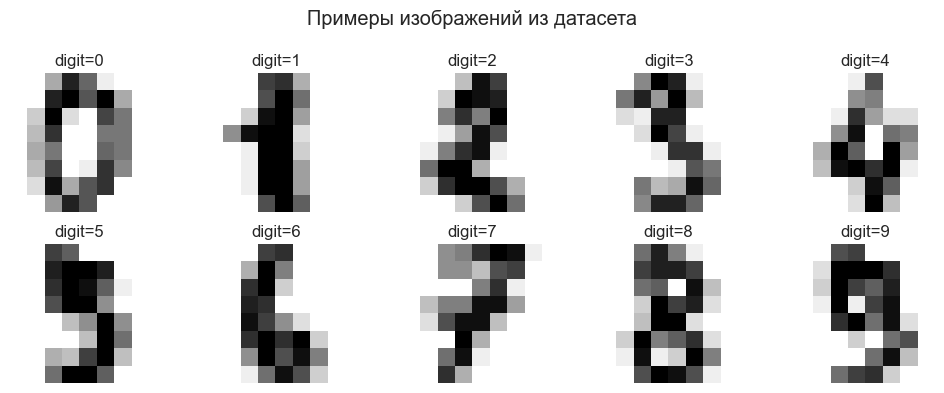

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, label in zip(axes.ravel(), digits.images[:10], y_true[:10]):
    ax.imshow(image, cmap="gray_r")
    ax.set_title(f"digit={label}")
    ax.axis("off")
plt.suptitle("Примеры изображений из датасета")
plt.tight_layout()
plt.show()

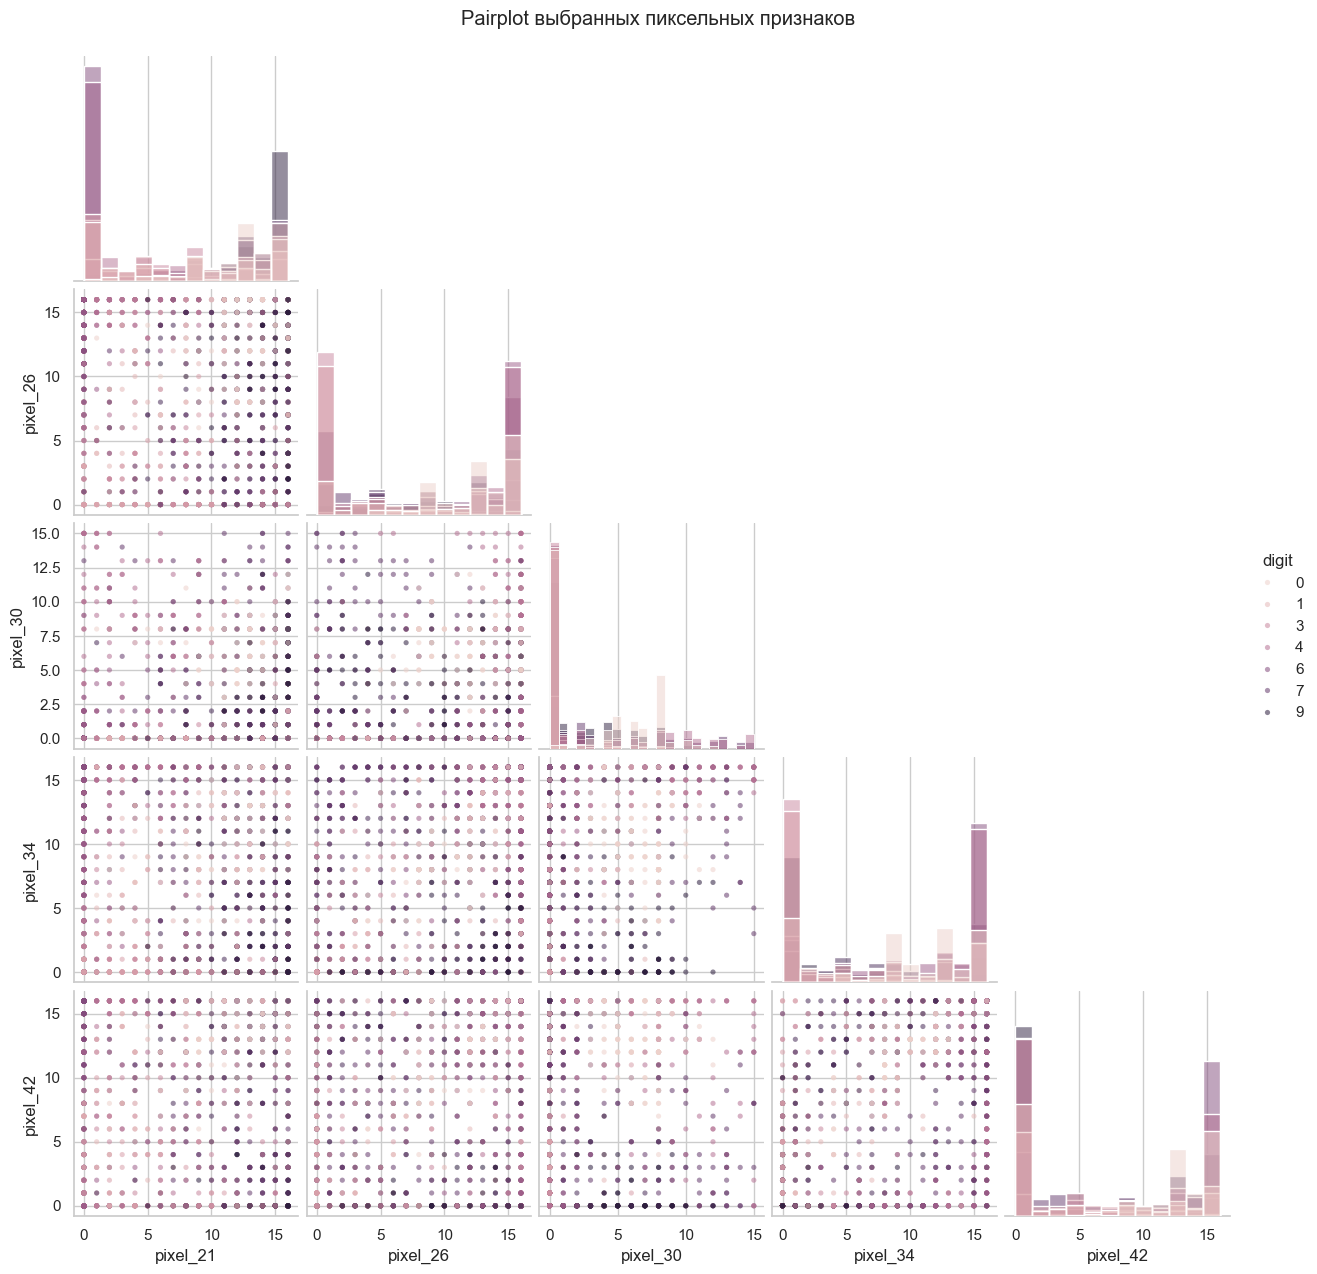

In [4]:
selected_features = ["pixel_21", "pixel_26", "pixel_30", "pixel_34", "pixel_42"]
sns.pairplot(
    df[selected_features + ["digit"]],
    hue="digit",
    corner=True,
    plot_kws={"s": 14, "alpha": 0.55, "edgecolor": "none"},
    diag_kind="hist",
)
plt.suptitle("Pairplot выбранных пиксельных признаков", y=1.02)
plt.show()

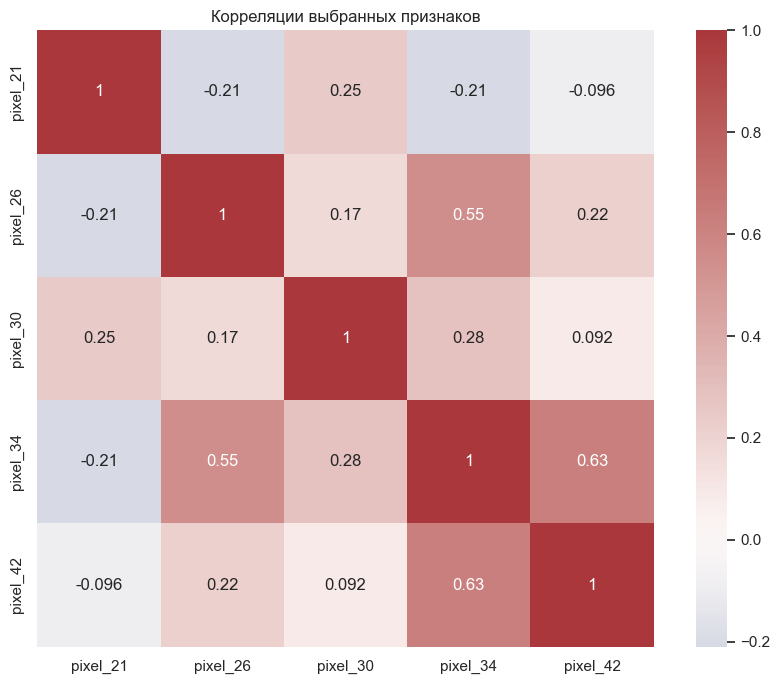

In [5]:
plt.figure(figsize=(9, 7))
corr = df[selected_features].corr()
sns.heatmap(corr, annot=True, cmap="vlag", center=0, square=True)
plt.title("Корреляции выбранных признаков")
plt.tight_layout()
plt.show()

In [ ]:
visualizer = HighDimVisualizer(random_state=RANDOM_STATE)

X, y, names = visualizer.prepare_dataset(
    digits,
    scale=True,
    max_samples=1000,
)

cluster_labels, kmeans = visualizer.cluster_dataset(
    X,
    method="kmeans",
    n_clusters=10,
)

print("Подготовленная форма X:", X.shape)
print("Найденные кластеры:", np.unique(cluster_labels))

Подготовленная форма X: (1000, 64)
Найденные кластеры: [0 1 2 3 4 5 6 7 8 9]


In [7]:
ari = adjusted_rand_score(y, cluster_labels)
silhouette = silhouette_score(X, cluster_labels)

print(f"Adjusted Rand Index: {ari:.3f}")
print(f"Silhouette score: {silhouette:.3f}")

cluster_table = pd.crosstab(
    pd.Series(cluster_labels, name="cluster"),
    pd.Series(y, name="true_digit"),
)
display(cluster_table)

Adjusted Rand Index: 0.475
Silhouette score: 0.142


true_digit,0,1,2,3,4,5,6,7,8,9
cluster,,,,,,,,,,
0,0,54,11,0,1,0,2,6,48,0
1,0,13,29,0,0,0,0,0,0,3
2,100,0,0,0,0,0,0,0,0,0
3,0,0,51,3,0,16,0,3,5,0
4,0,0,0,94,0,30,0,0,27,77
5,0,0,3,12,3,45,0,64,14,10
6,0,0,0,0,94,1,0,2,0,0
7,0,0,0,0,0,2,97,0,2,0
8,0,38,1,0,4,1,1,1,2,11


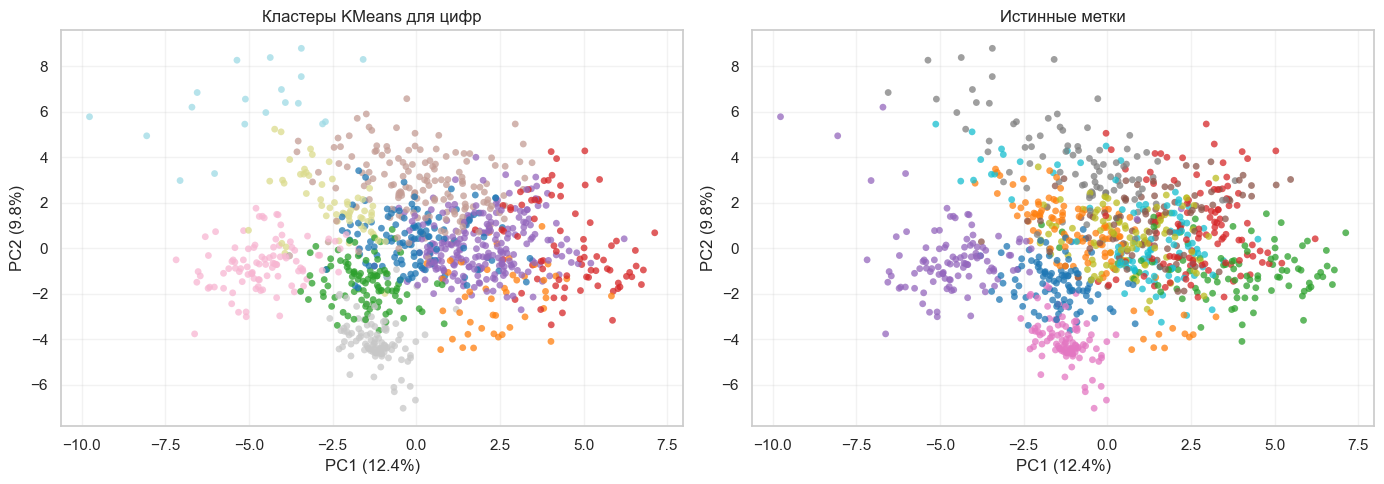

Доля дисперсии в 2D PCA: [0.124 0.098]


In [8]:
X_pca_2d, pca_2d = visualizer.plot_cluster_projection(
    X,
    cluster_labels,
    title="Кластеры KMeans для цифр",
    target=y,
)

print("Доля дисперсии в 2D PCA:", pca_2d.explained_variance_ratio_.round(3))

In [9]:
fig, X_pca_3d, pca_3d = visualizer.plot_interactive_3d_clusters(
    X,
    cluster_labels,
    target=y,
    output_file="interactive_3d_plot.html",
    title="Кластеры KMeans для цифр",
)

print("Доля дисперсии в 3D PCA:", pca_3d.explained_variance_ratio_.round(3))
print("Интерактивный график сохранён в interactive_3d_plot.html")

Доля дисперсии в 3D PCA: [0.124 0.098 0.086]
Интерактивный график сохранён в interactive_3d_plot.html


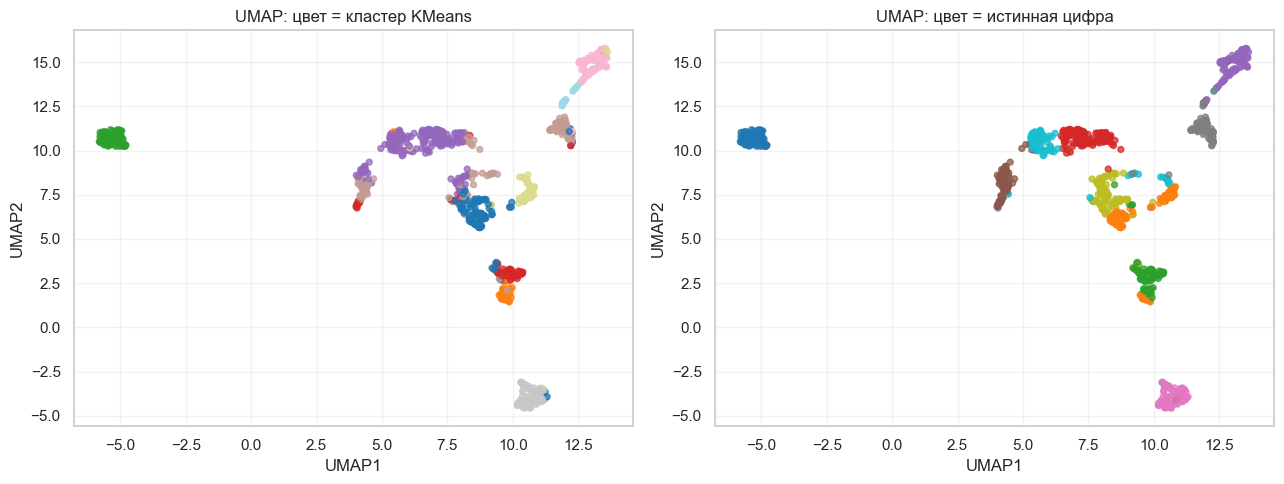

In [10]:
try:
    import umap

    reducer = umap.UMAP(
        n_neighbors=20,
        min_dist=0.05,
        n_components=2,
        random_state=RANDOM_STATE,
    )
    X_umap = reducer.fit_transform(X)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].scatter(X_umap[:, 0], X_umap[:, 1], c=cluster_labels, cmap="tab20", s=18, alpha=0.75)
    axes[0].set_title("UMAP: цвет = кластер KMeans")
    axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap="tab10", s=18, alpha=0.75)
    axes[1].set_title("UMAP: цвет = истинная цифра")
    for ax in axes:
        ax.set_xlabel("UMAP1")
        ax.set_ylabel("UMAP2")
        ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("umap-learn не установлен. Установите пакет командой: %pip install umap-learn")